# Dense Retrieval Autoresearch — Experiment Analysis

Analysis of autonomous dense retrieval experiments on Robust04.
- **Metrics**: MAP@1000, MAP@100, nDCG@10, Recall@100
- **BM25+PRF baseline**: MAP@1000 = 0.2739 (uncut MAP, matches pyterrier's `"map"` metric)
- **Note**: MAP@100 ≠ MAP@1000. Our BM25+Bo1 scores MAP@1000=0.2739 but MAP@100=0.2325. The 0.2746 target from prior experiments used uncut MAP.
- **Data**: `results.tsv` at project root

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Load from root results.tsv
tsv_path = Path("results.tsv")
df = pd.read_csv(tsv_path, sep="\t")

# Clean numeric columns (-1 means missing)
numeric_cols = ["ndcg@10", "map@1000", "map@100", "recall@100", "memory_gb", "eval_dur"]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df.loc[df[col] == -1, col] = np.nan

df["status"] = df["status"].str.strip().str.lower()
df["exp_num"] = range(len(df))

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df

Total experiments: 121
Columns: ['commit', 'ndcg@10', 'map@1000', 'map@100', 'recall@100', 'memory_gb', 'eval_dur', 'status', 'encoder', 'batch', 'doc_len', 'lr', 'description', 'worktree', 'exp_num']


,commit,ndcg@10,map@1000,map@100,recall@100,memory_gb,eval_dur,status,encoder,batch,doc_len,lr,description,worktree,exp_num
0,d30ed59,0.352147,NaN,0.126045,NaN,8.6,NaN,keep,MiniLM-L6-v2,128.0,180.0,2e-5,baseline: MiniLM-L6-v2 InfoNCE batch=128,mar16,0
1,941a194,0.397801,NaN,0.149852,NaN,16.7,NaN,keep,e5-small-v2,128.0,180.0,2e-5,exp1: e5-small-v2 with query/passage prefixes,mar16,1
2,484cbec,0.000000,NaN,0.000000,0.0,0.0,NaN,crash,e5-small-v2,256.0,180.0,2e-5,exp2: batch=256 OOM on GPU,mar16,2
3,964fb3d,0.000000,NaN,0.000000,0.0,0.0,NaN,crash,e5-base-v2,128.0,180.0,2e-5,exp3: e5-base-v2 OOM during training,mar16,3
4,6f690b6,0.395621,NaN,NaN,NaN,16.7,NaN,discard,e5-small-v2,128.0,180.0,2e-5,exp4: cosine warmup LR (below exp1),mar16,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,NaN,0.459430,0.246696,0.453118,0.0,23.4,NaN,bm25+bo1,NaN,NaN,NaN,"BM25(k1=0.9,b=0.5)+Bo1(fbDocs=3,fbTerms=20)",exp20-bm25-tuning,NaN,116
117,NaN,0.460470,0.246766,0.454736,0.0,33.3,NaN,bm25+bo1,NaN,NaN,NaN,"BM25(k1=0.9,b=0.5)+Bo1(fbDocs=3,fbTerms=30)",exp20-bm25-tuning,NaN,117
118,NaN,0.460816,0.246919,0.453557,0.0,58.6,NaN,bm25+bo1,NaN,NaN,NaN,"BM25(k1=0.9,b=0.5)+Bo1(fbDocs=3,fbTerms=50)",exp20-bm25-tuning,NaN,118
119,NaN,0.460432,0.244787,0.449180,0.0,16.4,NaN,bm25+bo1,NaN,NaN,NaN,"BM25(k1=0.9,b=0.5)+Bo1(fbDocs=5,fbTerms=10)",exp20-bm25-tuning,NaN,119


In [2]:
# Experiment outcomes
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("keep", 0)
n_discard = counts.get("discard", 0)
n_crash = counts.get("crash", 0)
n_total = len(df)
n_decided = n_keep + n_discard

print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep/n_decided:.1%}" if n_decided else "")
print(f"Crash rate: {n_crash}/{n_total} = {n_crash/n_total:.1%}" if n_total else "")

Experiment outcomes:
status
keep        100
bm25+bo1      9
crash         6
discard       6

Keep rate: 100/106 = 94.3%
Crash rate: 6/121 = 5.0%


In [3]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "keep"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
print(f"{'#':>3}  {'MAP@100':>8}  {'nDCG@10':>8}  {'R@100':>7}  {'Mem':>5}  {'EvalDur':>8}  Description")
print("-" * 100)
for i, row in kept.iterrows():
    map_s = f"{row['map@100']:.4f}" if pd.notna(row.get('map@100')) else "  N/A "
    ndcg_s = f"{row['ndcg@10']:.4f}" if pd.notna(row.get('ndcg@10')) else "  N/A "
    rec_s = f"{row['recall@100']:.4f}" if pd.notna(row.get('recall@100')) else " N/A "
    mem_s = f"{row['memory_gb']:.1f}" if pd.notna(row.get('memory_gb')) else " N/A"
    dur_s = f"{row['eval_dur']:.0f}s" if pd.notna(row.get('eval_dur')) else "  N/A "
    print(f"{i:3d}  {map_s:>8}  {ndcg_s:>8}  {rec_s:>7}  {mem_s:>5}  {dur_s:>8}  {row['description']}")

KEPT experiments (100 total):

  #   MAP@100   nDCG@10    R@100    Mem   EvalDur  Description
----------------------------------------------------------------------------------------------------
  0    0.1260    0.3521     N/A     8.6      N/A   baseline: MiniLM-L6-v2 InfoNCE batch=128
  1    0.1499    0.3978     N/A    16.7      N/A   exp1: e5-small-v2 with query/passage prefixes
  5      N/A     0.3996     N/A    16.7      N/A   exp5: temperature=0.05
  6      N/A     0.4109     N/A    16.7      N/A   exp6: symmetric in-batch negatives
  7      N/A     0.4129     N/A    16.7      N/A   exp7: LR=1e-5 conservative fine-tuning
  8      N/A     0.4256     N/A    17.1      N/A   exp8: e5-base-v2 batch=64 ENCODE_BATCH=256
 12      N/A     0.4365     N/A    19.6      N/A   exp12: MAX_DOC_LEN=220
 15    0.1772    0.4421     N/A    19.6      N/A   exp15: MAX_QUERY_LEN=96 for verbose TREC topics
 18    0.1996    0.4743   0.3525   19.6      N/A   exp16: cross-encoder rerank top-100
 19    0.222

## Metric Progress Over Time

Track MAP@1000, MAP@100, nDCG@10, Recall@100 across experiments. BM25+PRF target line uses MAP@1000=0.2739 (uncut MAP, comparable to pyterrier's `"map"` metric). MAP@100 target shown separately at 0.2325.

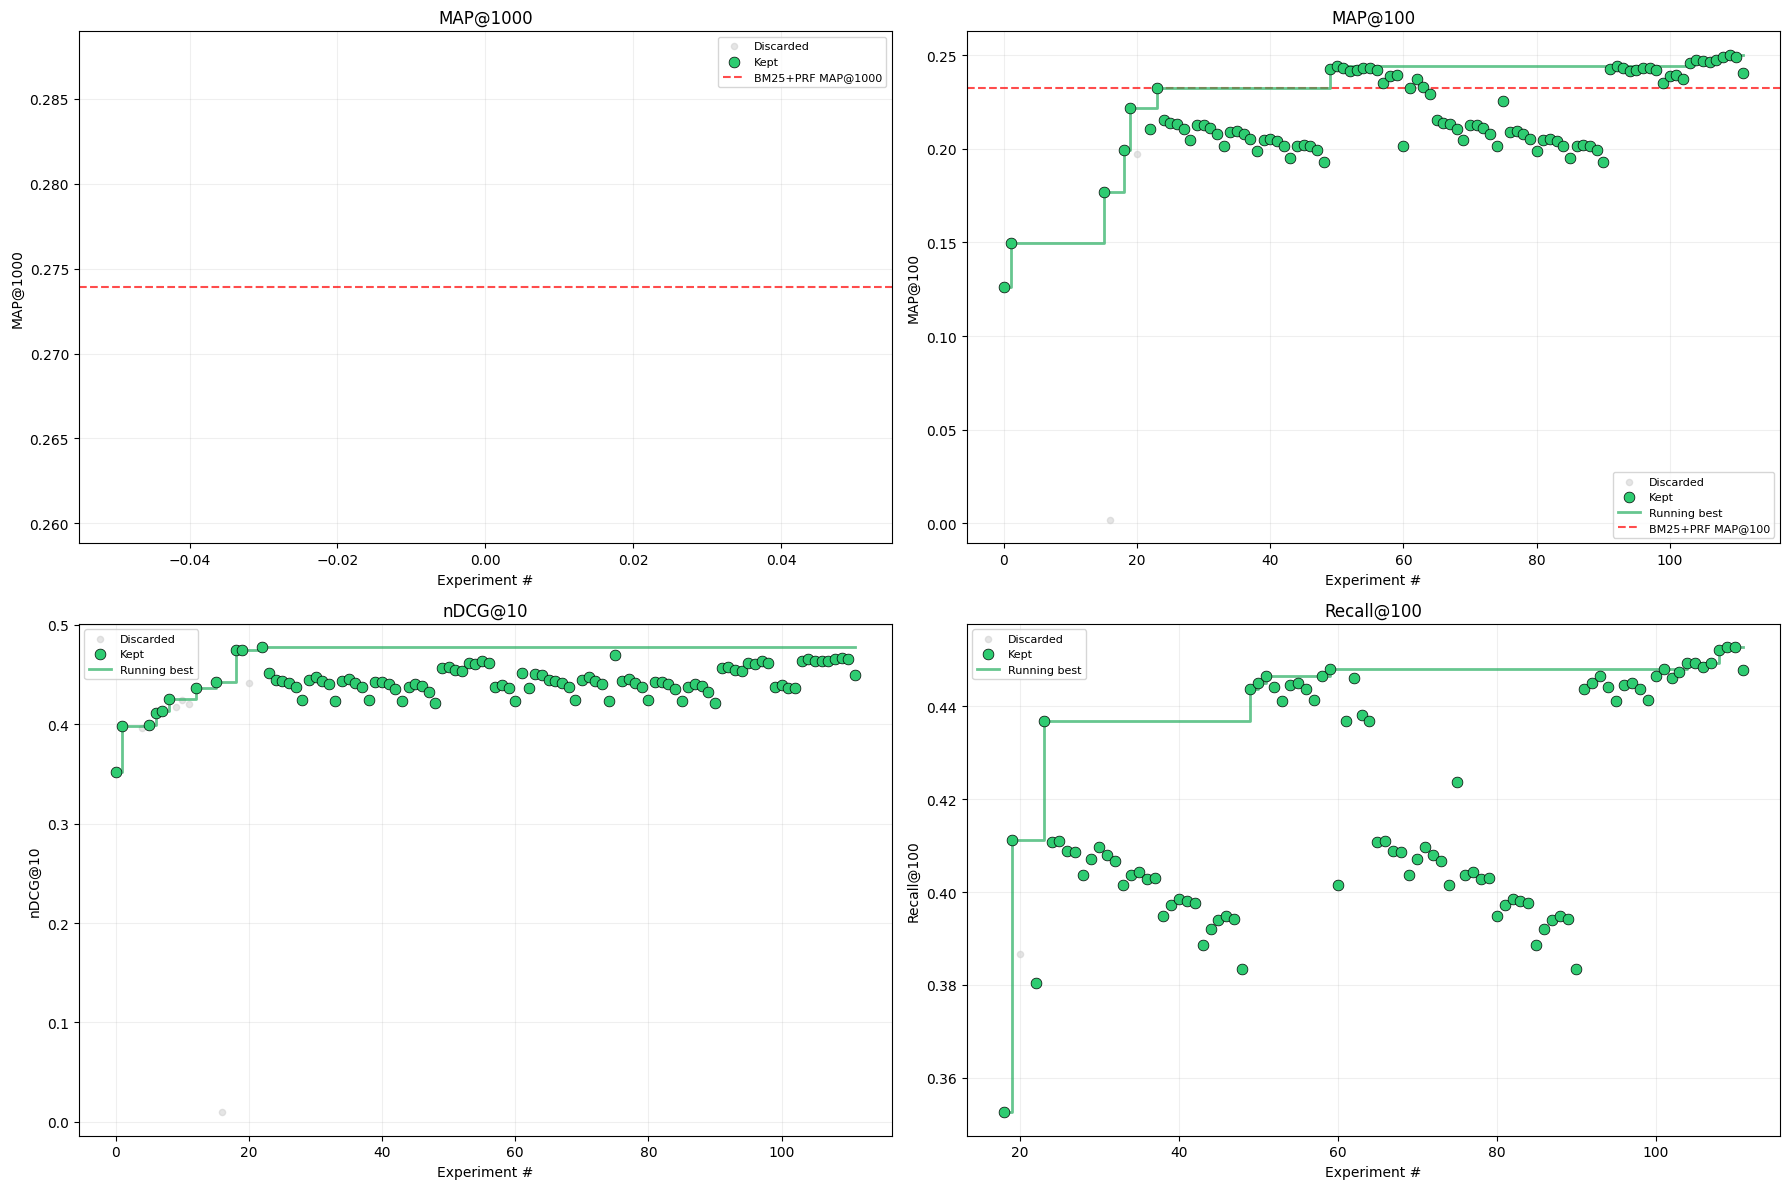

Saved to progress.png


In [4]:
BM25_PRF_MAP1000 = 0.2739  # uncut MAP (matches pyterrier "map" metric)
BM25_PRF_MAP100 = 0.2325   # MAP@100

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

metrics_config = [
    ("map@1000", "MAP@1000", BM25_PRF_MAP1000, "BM25+PRF MAP@1000"),
    ("map@100", "MAP@100", BM25_PRF_MAP100, "BM25+PRF MAP@100"),
    ("ndcg@10", "nDCG@10", None, None),
    ("recall@100", "Recall@100", None, None),
]

for ax, (metric, title, target, target_label) in zip(axes, metrics_config):
    valid = df[df["status"] != "crash"].copy()
    valid = valid.dropna(subset=[metric])
    if valid.empty:
        ax.set_title(f"{title} — no data")
        continue

    # Discarded as faint dots
    disc = valid[valid["status"] == "discard"]
    ax.scatter(disc["exp_num"], disc[metric], c="#cccccc", s=20, alpha=0.5, zorder=2, label="Discarded")

    # Kept as green dots
    kept_v = valid[valid["status"] == "keep"]
    ax.scatter(kept_v["exp_num"], kept_v[metric], c="#2ecc71", s=60, zorder=4,
               label="Kept", edgecolors="black", linewidths=0.5)

    # Running max line
    if not kept_v.empty:
        running_max = kept_v[metric].cummax()
        ax.step(kept_v["exp_num"].values, running_max.values, where="post",
                color="#27ae60", linewidth=2, alpha=0.7, zorder=3, label="Running best")

    # Target line
    if target is not None:
        ax.axhline(y=target, color="red", linestyle="--", alpha=0.7, label=target_label)

    ax.set_xlabel("Experiment #")
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Method Comparison

Compare different encoder models and pipeline configurations.

Best MAP@100 per encoder/method:
                              map@100  ndcg@10  recall@100  memory_gb
encoder                                                              
BM25+Bo1                       0.2504   0.4662      0.4528     0.0000
bm25_kl_fbdocs:3&fbterms:10    0.2332   0.4502      0.4381     0.0000
bm25_bo1_fbdocs:3&fbterms:10   0.2325   0.4517      0.4369     0.0000
bm25_rm3_fbdocs:3&fbterms:10   0.2293   0.4491      0.4370     0.0000
BM25+Bo1+reranker              0.2258   0.4697      0.4238     0.2000
e5-base-v2+reranker            0.2220   0.4775      0.4111    19.6000
BM25                           0.2153   0.4470      0.4109     0.0000
bm25_default                   0.2018   0.4238      0.4016     0.0000
e5-base-v2+L12-reranker        0.1971   0.4412      0.3867    19.6000
e5-base-v2                     0.1772   0.4421         NaN    19.6000
e5-small-v2                    0.1499   0.3978         NaN    16.7000
MiniLM-L6-v2                   0.1260   0.3521         Na

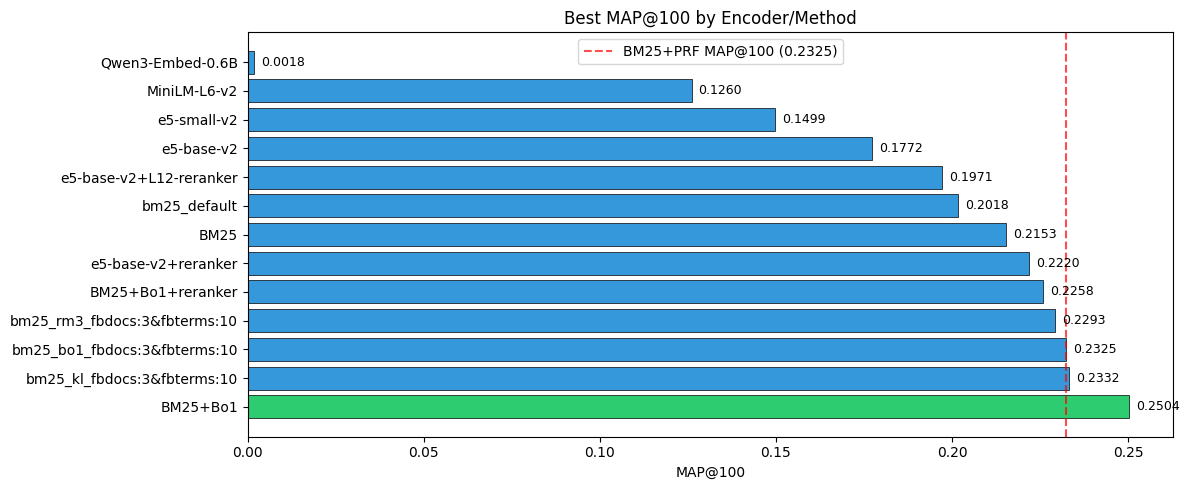

In [5]:
# Group by encoder and show best result per encoder
valid = df[(df["status"] != "crash") & df["map@100"].notna()].copy()

if not valid.empty:
    best_per_encoder = valid.groupby("encoder").agg({
        "map@100": "max",
        "ndcg@10": "max",
        "recall@100": "max",
        "memory_gb": "mean",
    }).sort_values("map@100", ascending=False)

    print("Best MAP@100 per encoder/method:")
    print(best_per_encoder.to_string(float_format=lambda x: f"{x:.4f}"))
    print()

    fig, ax = plt.subplots(figsize=(12, 5))
    encoders = best_per_encoder.index.tolist()
    maps = best_per_encoder["map@100"].values
    colors = ["#2ecc71" if m == maps.max() else "#3498db" for m in maps]
    bars = ax.barh(encoders, maps, color=colors, edgecolor="black", linewidth=0.5)
    ax.axvline(x=BM25_PRF_MAP100, color="red", linestyle="--", alpha=0.7, label=f"BM25+PRF MAP@100 ({BM25_PRF_MAP100})")
    ax.set_xlabel("MAP@100")
    ax.set_title("Best MAP@100 by Encoder/Method")
    ax.legend()
    for bar, val in zip(bars, maps):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, f"{val:.4f}", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()

## Incremental Improvements (Kept Experiments)

Each kept experiment's delta is measured vs the previous kept experiment's MAP@100.

In [6]:
# Incremental improvements for MAP@100
kept = df[df["status"] == "keep"].copy()
kept_with_map = kept.dropna(subset=["map@100"])

if len(kept_with_map) >= 2:
    kept_with_map = kept_with_map.copy()
    kept_with_map["prev_map"] = kept_with_map["map@100"].shift(1)
    kept_with_map["delta"] = kept_with_map["map@100"] - kept_with_map["prev_map"]
    hits = kept_with_map.iloc[1:].copy()

    # Sort by delta
    hits_sorted = hits.sort_values("delta", ascending=False)

    print(f"{'Rank':>4}  {'Delta':>9}  {'MAP@100':>8}  Description")
    print("-" * 85)
    for rank, (_, row) in enumerate(hits_sorted.iterrows(), 1):
        print(f"{rank:4d}  {row['delta']:+.6f}  {row['map@100']:.6f}  {row['description']}")
    print(f"\n{'':>4}  {hits['delta'].sum():+.6f}  {'':>8}  TOTAL improvement over first tracked MAP")
else:
    print("Not enough kept experiments with MAP@100 data")

# Also show nDCG@10 improvements
print("\n--- nDCG@10 progression (kept only) ---")
kept_ndcg = kept.dropna(subset=["ndcg@10"])
if not kept_ndcg.empty:
    kept_ndcg = kept_ndcg.copy()
    kept_ndcg["prev"] = kept_ndcg["ndcg@10"].shift(1)
    kept_ndcg["delta"] = kept_ndcg["ndcg@10"] - kept_ndcg["prev"]
    for _, row in kept_ndcg.iterrows():
        d = f"{row['delta']:+.4f}" if pd.notna(row["delta"]) else "  base"
        print(f"  nDCG@10={row['ndcg@10']:.4f}  {d:>8}  {row['description']}")

Rank      Delta   MAP@100  Description
-------------------------------------------------------------------------------------
   1  +0.050139  0.242906  BM25(k1=0.9,b=0.3)+Bo1(fbDocs=3,fbTerms=10)
   2  +0.050139  0.242906  BM25(k1=0.9,b=0.3)+Bo1(fbDocs=3,fbTerms=10)
   3  +0.030719  0.232505  bm25_bo1_fbdocs:3&fbterms:10 (Oleg config)
   4  +0.027373  0.177225  exp15: MAX_QUERY_LEN=96 for verbose TREC topics
   5  +0.023989  0.225775  exp21: BM25+Bo1(3,10) -> MiniLM-L-6 rerank top-1000
   6  +0.023807  0.149852  exp1: e5-small-v2 with query/passage prefixes
   7  +0.022409  0.221984  exp17: rerank top-1000 instead of top-100
   8  +0.022350  0.199575  exp16: cross-encoder rerank top-100
   9  +0.021918  0.232505  BM25+Bo1_PRF baseline (fbDocs=3, fbTerms=10)
  10  +0.008543  0.246083  BM25(k1=0.9,b=0.4)+Bo1(fbDocs=3,fbTerms=10)
  11  +0.007792  0.212520  BM25(k1=1.2,b=0.3)
  12  +0.007792  0.212520  BM25(k1=1.2,b=0.3)
  13  +0.007220  0.209006  BM25(k1=1.5,b=0.3)
  14  +0.006684  0.2016

## Efficiency: MAP@100 vs Evaluation Time

Tradeoff between retrieval quality and total eval duration (encoding + indexing + retrieval + reranking).

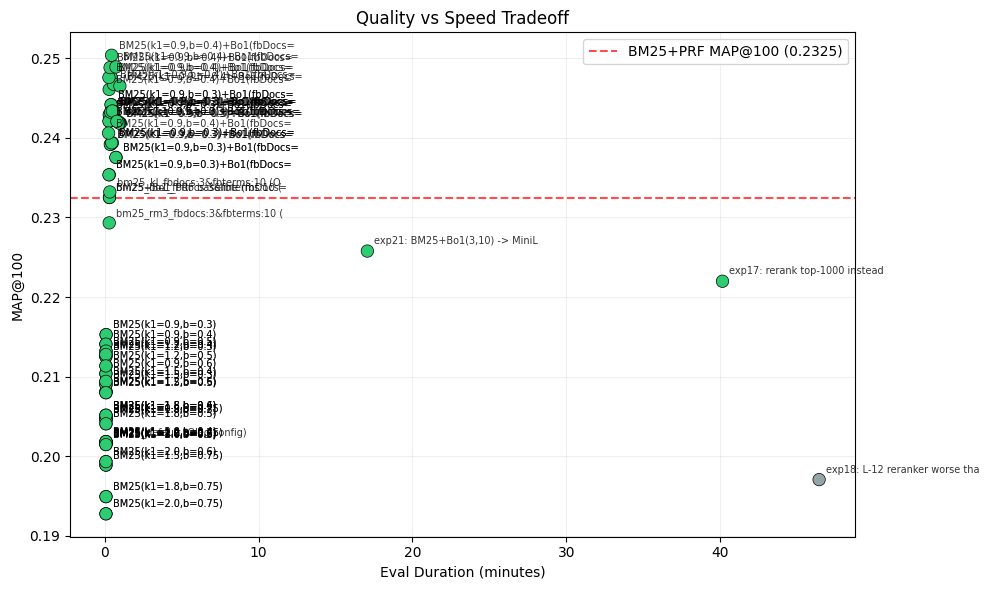

In [7]:
# MAP vs eval duration scatter
has_dur = df[(df["status"] != "crash") & df["eval_dur"].notna() & df["map@100"].notna()].copy()

if not has_dur.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ["#2ecc71" if s == "keep" else "#e74c3c" if s == "crash" else "#95a5a6"
              for s in has_dur["status"]]
    ax.scatter(has_dur["eval_dur"] / 60, has_dur["map@100"], c=colors, s=80,
               edgecolors="black", linewidths=0.5, zorder=3)

    for _, row in has_dur.iterrows():
        ax.annotate(row["description"][:30], (row["eval_dur"]/60, row["map@100"]),
                    textcoords="offset points", xytext=(5, 5), fontsize=7, alpha=0.8)

    ax.axhline(y=BM25_PRF_MAP100, color="red", linestyle="--", alpha=0.7, label=f"BM25+PRF MAP@100 ({BM25_PRF_MAP100})")
    ax.set_xlabel("Eval Duration (minutes)")
    ax.set_ylabel("MAP@100")
    ax.set_title("Quality vs Speed Tradeoff")
    ax.legend()
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print("No experiments with both eval_dur and MAP@100 data yet")

## VRAM Usage by Method

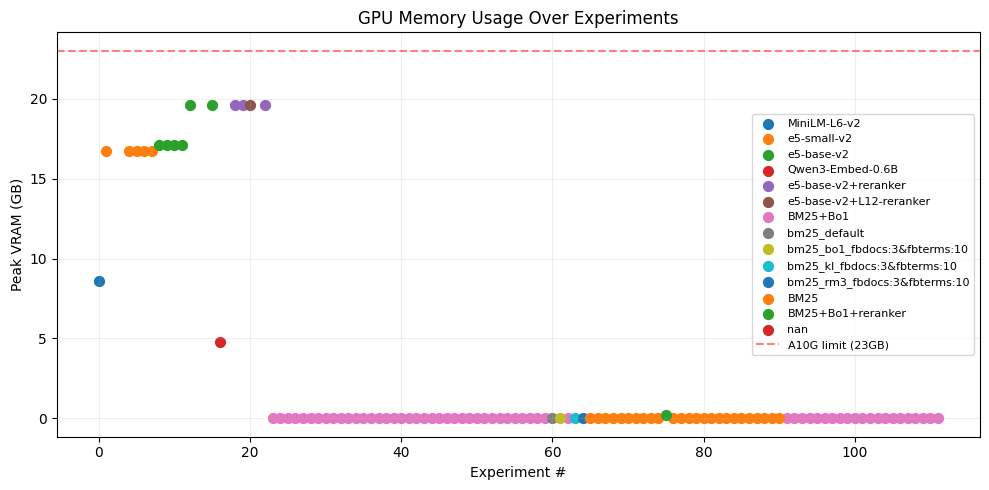

In [8]:
# VRAM usage by encoder
valid = df[(df["status"] != "crash") & df["memory_gb"].notna()].copy()
if not valid.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    for encoder in valid["encoder"].unique():
        subset = valid[valid["encoder"] == encoder]
        ax.scatter(subset["exp_num"], subset["memory_gb"], label=encoder, s=50)
    ax.axhline(y=23.0, color="red", linestyle="--", alpha=0.5, label="A10G limit (23GB)")
    ax.set_xlabel("Experiment #")
    ax.set_ylabel("Peak VRAM (GB)")
    ax.set_title("GPU Memory Usage Over Experiments")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

## Summary

In [9]:
# Final summary
kept = df[df["status"] == "keep"]

print("=" * 60)
print("AUTORESEARCH SUMMARY")
print("=" * 60)
print(f"Total experiments:     {len(df)}")
print(f"  Kept:                {len(df[df['status']=='keep'])}")
print(f"  Discarded:           {len(df[df['status']=='discard'])}")
print(f"  Crashed:             {len(df[df['status']=='crash'])}")
print()

for metric, target, target_name in [
    ("map@1000", BM25_PRF_MAP1000, "BM25+PRF MAP@1000"),
    ("map@100", BM25_PRF_MAP100, "BM25+PRF MAP@100"),
    ("ndcg@10", None, None),
    ("recall@100", None, None),
]:
    valid = kept.dropna(subset=[metric])
    if valid.empty:
        print(f"Best {metric}: no data")
        continue
    best_row = valid.loc[valid[metric].idxmax()]
    print(f"Best {metric}:  {best_row[metric]:.6f}  ({best_row['description']})")
    if target:
        gap = target - best_row[metric]
        if gap > 0:
            print(f"  Gap to {target_name}: {gap:.6f}")
        else:
            print(f"  BEATS {target_name} by: {-gap:.6f}")

print("=" * 60)

AUTORESEARCH SUMMARY
Total experiments:     121
  Kept:                100
  Discarded:           6
  Crashed:             6

Best map@1000: no data
Best map@100:  0.250376  (BM25(k1=0.9,b=0.4)+Bo1(fbDocs=5,fbTerms=30))
  BEATS BM25+PRF MAP@100 by: 0.017876
Best ndcg@10:  0.477463  (exp19: RERANK_TOP_K=200 new best nDCG@10)
Best recall@100:  0.452766  (BM25(k1=0.9,b=0.4)+Bo1(fbDocs=5,fbTerms=50))
